[@LorenaABarba](https://twitter.com/LorenaABarba)

通往 Navier–Stokes 方程的 12 个步骤
======
***

你好！欢迎来到 **通往 Navier–Stokes 方程的 12 个步骤**。这是一个实践性的模块，用于 [Lorena Barba 教授](http://lorenabarba.com) 自 2009 年春季起在波士顿大学讲授的交互式计算流体力学（CFD）课程的开篇部分。本课程只要求具备基本的编程知识（任何语言均可），当然还需要一些偏微分方程和流体力学的基础。这个实践模块的灵感来自 Rio Yokota 博士的想法，他曾是 Barba 实验室的博士后；此后 Barba 教授和她的学生们在多个学期的教学中不断完善它。整个课程完全使用 Python 讲授，不会 Python 的学生就在学习模块的过程中边做边学。

这个 [Jupyter notebook](https://jupyter-notebook.readthedocs.io/en/stable/) 将带你完成第一步——从零开始用 Python 编写你自己的 Navier–Stokes 求解器。我们将直接切入正题。如果一开始你并不能理解所有内容，不必担心，随着学习的深入我们会详细讲解，你也可以借助 [Barba 教授在 YouTube 上的讲座视频](http://www.youtube.com/playlist?list=PL30F4C5ABCE62CB61) 来辅助学习。

为了取得最佳效果，在跟随本 notebook 学习之后，请你自己准备第 1 步的代码，可以是一个 Python 脚本，也可以是一个全新的 Jupyter notebook。

要运行本 Notebook，我们假设你已经通过以下命令启动了 notebook 服务器：`jupyter notebook`。

第 1 步：一维线性对流
-----
***

一维线性对流方程是可用于学习 CFD 的最简单、最基本的模型。令人惊讶的是，这个小小的方程竟能教会我们如此之多！它是这样的：

$$\frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x} = 0$$

在给定初始条件（可理解为一个*波*）的情况下，该方程表示这个初始*波*以速度 $c$ 传播，且形状保持不变。设初始条件为 $u(x,0)=u_0(x)$，则方程的精确解为 $u(x,t)=u_0(x-ct)$。

我们在空间和时间上都对该方程进行离散：对时间导数使用前向差分格式，对空间导数使用后向差分格式。考虑将空间坐标 $x$ 离散为一系列点，索引从 $i=0$ 到 $N$，并以大小为 $\Delta t$ 的离散时间间隔逐步推进。

根据导数的定义（直接去掉极限），我们知道：

$$\frac{\partial u}{\partial x}\approx \frac{u(x+\Delta x)-u(x)}{\Delta x}$$

于是，我们的离散方程为：

$$\frac{u_i^{n+1}-u_i^n}{\Delta t} + c \frac{u_i^n - u_{i-1}^n}{\Delta x} = 0 $$

其中 $n$ 和 $n+1$ 是时间上相邻的两个步，而 $i-1$ 和 $i$ 是离散化 $x$ 坐标上相邻的两个点。若给定初始条件，则此离散式中唯一的未知量便是 $u_i^{n+1}$。我们可以求解该未知量，得到一个能让我们在时间上推进的方程，如下所示：

$$u_i^{n+1} = u_i^n - c \frac{\Delta t}{\Delta x}(u_i^n-u_{i-1}^n)$$

现在，让我们试着用 Python 来实现它。

我们先导入几个有用的库：

* `numpy` 是一个提供大量实用矩阵运算的库，类似于 MATLAB
* `matplotlib` 是一个二维绘图库，我们将用它来绘制结果
* `time` 和 `sys` 提供基本的计时功能，我们用它们来放慢动画以便观看

In [12]:
# 记住：Python 中的注释用井号（#）表示
import numpy                       # 这里我们加载 numpy
from matplotlib import pyplot      # 这里我们加载 matplotlib
import time, sys                   # 再加载一些工具库


In [13]:
# 这一行让 matplotlib 的图显示在 notebook 中（而不是单独的窗口里）
%matplotlib inline                  

现在我们来定义几个变量；我们希望在一个宽 2 个长度单位的空间域内定义一组均匀分布的网格点，即 $x_i\in(0,2)$。我们将定义一个变量 `nx` 表示想要的网格点数，`dx` 则表示任意一对相邻网格点之间的距离。

In [14]:
nx = 500  # 试着把这个数字从 41 改到 81，然后 Run All……会发生什么？
dx = 10 / (nx-1)
nt = 100    # nt 是我们想要计算的时间步数
dt = .025  # dt 是每个时间步所覆盖的时间量（delta t）
c = 1      # 假设波速 c = 1

我们还需要设置初始条件。初始速度 $u_0$ 定义为：在区间 $0.5 \leq x \leq 1$ 内 $u = 2$，在 $(0,2)$ 内其余地方 $u = 1$（即一个矩形/帽子函数）。

这里我们使用 `ones()` 函数定义一个长度为 `nx`、每个值都等于 1 的 `numpy` 数组。

In [15]:
u = numpy.ones(nx)      # numpy 的 ones() 函数
u[int(.5 / dx):int(1 / dx + 1)] = 2  # 按照初始条件，把 0.5 到 1 之间的 u 设为 2
print(u)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.

现在我们用 Matplotlib 绘图来看一看这些初始条件。我们已经导入了 `matplotlib` 的绘图库 `pyplot`，其绘图函数名为 `plot`，因此我们调用 `pyplot.plot`。要了解 Matplotlib 的无数可能性，可以浏览示例图的[画廊](http://matplotlib.org/gallery.html)。

这里我们使用简单二维绘图的语法：`plot(x,y)`，其中 `x` 值是均匀分布的网格点：

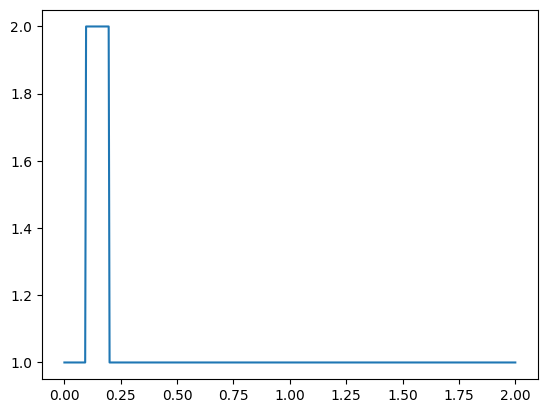

In [16]:
pyplot.plot(numpy.linspace(0, 2, nx), u);

为什么这个帽子函数的两侧不是完全竖直的？想一想。

现在该用有限差分格式来实现对流方程的离散了。

对于数组 `u` 的每个元素，我们都需要执行运算 $u_i^{n+1} = u_i^n - c \frac{\Delta t}{\Delta x}(u_i^n-u_{i-1}^n)$

我们会把结果存储在一个新的（临时）数组 `un` 中，它就是下一个时间步的解 $u$。我们会将这个运算重复我们所指定的时间步数，然后就能看到波传播了多远。

我们首先初始化占位数组 `un`，用来保存我们为第 $n+1$ 时间步计算出的值，同样使用 NumPy 的 `ones()` 函数。

接下来，我们可能会认为这里有两个迭代运算：一个在空间上，一个在时间上（稍后我们会学到不同的做法），所以我们先把一个循环嵌套在另一个里面。注意这里用到了巧妙的 `range()` 函数。当我们写 `for i in range(1,nx)` 时，我们会遍历 `u` 数组，但会跳过第一个元素（第 0 个元素）。*为什么呢？*

In [17]:
un = numpy.ones(nx) # 初始化一个临时数组

for n in range(nt):  # 让 n 从 0 循环到 nt，因此会运行 nt 次
    un = u.copy() ## 把 u 现有的值复制到 un 中
    for i in range(1, nx): ## 你可以试着把这一行注释掉，然后……
    #for i in range(nx): ## ……取消这一行的注释，看看会发生什么！
        u[i] = un[i] - c * dt / dx * (un[i] - un[i-1])

        

**注意**——稍后我们会学到，上面这样写的代码效率相当低，用 Python 的风格有更好的写法。不过我们先继续。

现在我们来试着绘制在时间上推进后的 `u` 数组。

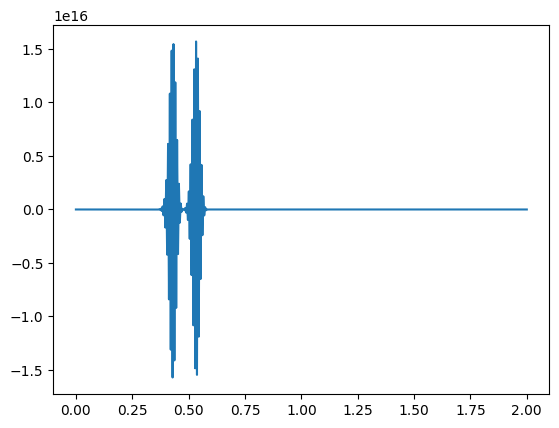

In [18]:
pyplot.plot(numpy.linspace(0, 2, nx), u);

好的！我们的帽子函数确实向右移动了，但它已经不再是一个帽子形状了。**这是怎么回事？**

了解更多
-----
***

要更深入地了解有限差分方法，包括截断误差、收敛阶数等细节，请观看 Barba 教授在 YouTube 上的 **视频课 2 和 3**。

In [19]:
from IPython.display import YouTubeVideo
YouTubeVideo('iz22_37mMkk')

In [20]:
YouTubeVideo('xq9YTcv-fQg')

要仔细了解用有限差分对线性对流方程进行离散的完整推导（以及后续步骤，直到第 4 步），请观看 Barba 教授在 YouTube 上的 **视频课 4**。

In [21]:
YouTubeVideo('y2WaK7_iMRI')

## 最后但同样重要

**记得** 把第 1 步重新写成一个全新的 Python 脚本，或写在*你自己的* Jupyter notebook 里，然后通过改变离散参数来做实验。完成之后，你就可以准备进入 [第 2 步](../step_2/step_2.ipynb) 了。


***

In [22]:
from IPython.core.display import HTML
def css_styling():
    styles = open("../../styles/custom.css", "r").read()
    return HTML(styles)
css_styling()

> （上面的单元格执行了本 notebook 的样式设置。我们修改了在 [CamDavidsonPilon](https://github.com/CamDavidsonPilon)（[@Cmrn_DP](https://twitter.com/cmrn_dp)）的 GitHub 上找到的一个样式。）